In [1]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU AKTİF ✅")
    except RuntimeError as e:
        print(e)
else:
    print("GPU BULUNAMADI ❌")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU AKTİF ✅


In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 64
ACCUM_STEPS = 2  # 64 x 2 = 128

EPOCHS_STAGE1 = 15
EPOCHS_STAGE2 = 30

TRAIN_DIR = "dataset/train"
VAL_DIR   = "dataset/val"
TEST_DIR  = "dataset/test"


In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [5]:
train_gen_base = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_gen_base.num_classes
print("Classes:", train_gen_base.class_indices)


Found 25173 images belonging to 7 classes.
Found 6206 images belonging to 7 classes.
Found 7659 images belonging to 7 classes.
Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [6]:
class DisgustOversampleGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_generator, disgust_idx, oversample_factor=2):
        self.base_gen = base_generator
        self.disgust_idx = disgust_idx
        self.oversample_factor = oversample_factor

    def __len__(self):
        return len(self.base_gen)

    def __getitem__(self, idx):
        x, y = self.base_gen[idx]

        mask = np.argmax(y, axis=1) == self.disgust_idx
        x_d, y_d = x[mask], y[mask]

        if len(x_d) > 0:
            x = np.concatenate([x] + [x_d] * (self.oversample_factor - 1), axis=0)
            y = np.concatenate([y] + [y_d] * (self.oversample_factor - 1), axis=0)

        return x, y


In [7]:
from sklearn.metrics import f1_score
import numpy as np

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_gen):
        super().__init__()
        self.val_gen = val_gen
        self.best_f1 = 0.0

    def on_epoch_end(self, epoch, logs=None):
        y_true = self.val_gen.classes
        y_pred = np.argmax(self.model.predict(self.val_gen, verbose=0), axis=1)

        macro_f1 = f1_score(y_true, y_pred, average="macro")
        logs["val_macro_f1"] = macro_f1

        print(f"\n🔎 val_macro_f1: {macro_f1:.4f}")

        if macro_f1 > self.best_f1:
            self.best_f1 = macro_f1
            self.model.save("best_macro_f1_model.h5")
            print("💾 Best Macro-F1 model saved!")


In [8]:
disgust_idx = train_gen_base.class_indices["disgust"]

train_gen = DisgustOversampleGenerator(
    base_generator=train_gen_base,
    disgust_idx=disgust_idx,
    oversample_factor=2
)

In [9]:
from tensorflow.keras import regularizers


In [10]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu",kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.4)(x)
outputs = Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

model = Model(inputs=base_model.input, outputs=outputs)


In [11]:
class AccumulationModel(tf.keras.Model):
    def __init__(self, accum_steps=2, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.accum_steps = accum_steps
        self.step_counter = tf.Variable(0, dtype=tf.int32, trainable=False)
        self.accum_grads = None

    def compile(self, *args, **kwargs):
        super().compile(*args, **kwargs)

        # trainable variables artık hazır
        self.accum_grads = [
            tf.Variable(tf.zeros_like(v), trainable=False)
            for v in self.trainable_variables
        ]

    def train_step(self, data):
        x, y = data

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = self.compiled_loss(y, y_pred)
            loss = loss / tf.cast(self.accum_steps, tf.float32)

        grads = tape.gradient(loss, self.trainable_variables)

        for i, g in enumerate(grads):
            self.accum_grads[i].assign_add(g)

        self.step_counter.assign_add(1)

        def apply_grads():
            self.optimizer.apply_gradients(
                zip(self.accum_grads, self.trainable_variables)
            )
            for g in self.accum_grads:
                g.assign(tf.zeros_like(g))
            return 0

        tf.cond(
            tf.equal(self.step_counter % self.accum_steps, 0),
            apply_grads,
            lambda: 0
        )

        self.compiled_metrics.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}


In [12]:
tf.keras.mixed_precision.set_global_policy("mixed_float16")

accum_model = AccumulationModel(
    accum_steps=ACCUM_STEPS,
    inputs=model.input,
    outputs=model.output
)
base_opt = Adam(learning_rate=2e-4)
optimizer = tf.keras.mixed_precision.LossScaleOptimizer(base_opt)
accum_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.07),
    metrics=["accuracy"]
)

callbacks_stage1 = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=4, factor=0.5)
]
steps_per_epoch = len(train_gen_base) // 2

history_stage1 = accum_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks_stage1
)


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4050 Laptop GPU, compute capability 8.9
Epoch 1/15
    with tf.GradientTape() as tape:
      loss = loss_fn()
      scaled_loss = opt.get_scaled_loss(loss)
    scaled_grads = tape.gradient(scaled_loss, vars)
    grads = opt.get_unscaled_gradients(scaled_grads)
    opt.apply_gradients([(grads, var)])
For more information, see https://www.tensorflow.org/api_docs/python/tf/keras/mixed_precision/LossScaleOptimizer
    with tf.GradientTape() as tape:
      loss = loss_fn()
      scaled_loss = opt.get_scaled_loss(loss)
    scaled_grads = tape.gradient(scaled_loss, vars)
    grads = opt.get_unscaled_gradients(scaled_grads)
    opt.apply_gradients([(grads, var)])
For more information, see https://www.tensorflow.org/api_docs/python/tf/keras/mixed_precision/LossScaleOptimizer
197/197 [==

In [26]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
# class index -> label listesi
class_indices = train_gen_base.class_indices

# index -> class name
idx_to_class = {v: k for k, v in class_indices.items()}

# -----------------------------------------
# 2) Train sınıf dağılımı (örnek sayıları)
# -----------------------------------------
y_train = train_gen_base.classes  # her örneğin sınıf index'i

counts = np.bincount(y_train, minlength=len(class_indices))

dist_df = pd.DataFrame({
    "class_index": list(range(len(class_indices))),
    "class_name": [idx_to_class[i] for i in range(len(class_indices))],
    "train_count": counts
}).sort_values("class_index").reset_index(drop=True)


print("\n=== Train Class Distribution ===")
print(dist_df.to_string(index=False))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
cw_df = pd.DataFrame({
    "class_index": list(class_weight_dict.keys()),
    "class_name": [idx_to_class[i] for i in class_weight_dict.keys()],
    "class_weight": [class_weight_dict[i] for i in class_weight_dict.keys()]
}).sort_values("class_index").reset_index(drop=True)

print("\n=== Class Weights (balanced) ===")
print(cw_df.to_string(index=False))
print("\nÖzet:")
print(f"Toplam train örnek sayısı: {counts.sum()}")
print(f"En az örnek: {dist_df.loc[dist_df.train_count.idxmin(),'class_name']} ({dist_df.train_count.min()})")
print(f"En çok örnek: {dist_df.loc[dist_df.train_count.idxmax(),'class_name']} ({dist_df.train_count.max()})")


=== Train Class Distribution ===
 class_index class_name  train_count
           0      angry         3507
           1    disgust          667
           2       fear         3590
           3      happy         6092
           4    neutral         4287
           5        sad         4176
           6   surprise         2854

=== Class Weights (balanced) ===
 class_index class_name  class_weight
           0      angry      1.025419
           1    disgust      5.391519
           2       fear      1.001711
           3      happy      0.590306
           4    neutral      0.838848
           5        sad      0.861145
           6   surprise      1.260036

Özet:
Toplam train örnek sayısı: 25173
En az örnek: disgust (667)
En çok örnek: happy (6092)


In [23]:
import numpy as np

# class index -> class name
idx_to_class = {v:k for k,v in train_gen_base.class_indices.items()}

counts = np.bincount(train_gen_base.classes)
for i, c in enumerate(counts):
    print(f"{idx_to_class[i]}: {c}")


angry: 3507
disgust: 667
fear: 3590
happy: 6092
neutral: 4287
sad: 4176
surprise: 2854


In [14]:
for layer in base_model.layers[-50:]:
    layer.trainable = True
model = tf.keras.Model(
    inputs=accum_model.input,
    outputs=accum_model.output
)

callbacks_stage2 = [
    EarlyStopping(
        monitor="val_macro_f1", 
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,      
        patience=3,     
        min_lr=3e-6,
        verbose=1
    )
]
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.07),
    metrics=["accuracy"]
)

history_stage2 = model.fit(
    train_gen_base,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    steps_per_epoch=len(train_gen_base),
    validation_steps=len(val_gen),
    callbacks=callbacks_stage2,
    class_weight=class_weight_dict,
    use_multiprocessing=False,
)


Epoch 1/30
394/394 [==============================] - 869s 2s/step - loss: 1.7493 - accuracy: 0.3396 - val_loss: 1.5892 - val_accuracy: 0.4397 - lr: 1.0000e-05
Epoch 2/30
394/394 [==============================] - 851s 2s/step - loss: 1.6119 - accuracy: 0.4143 - val_loss: 1.5964 - val_accuracy: 0.4372 - lr: 1.0000e-05
Epoch 3/30
394/394 [==============================] - 830s 2s/step - loss: 1.5378 - accuracy: 0.4492 - val_loss: 1.5667 - val_accuracy: 0.4517 - lr: 1.0000e-05
Epoch 4/30
394/394 [==============================] - 853s 2s/step - loss: 1.4849 - accuracy: 0.4771 - val_loss: 1.5173 - val_accuracy: 0.4770 - lr: 1.0000e-05
Epoch 5/30
394/394 [==============================] - 850s 2s/step - loss: 1.4431 - accuracy: 0.4954 - val_loss: 1.4736 - val_accuracy: 0.4936 - lr: 1.0000e-05
Epoch 6/30
394/394 [==============================] - 832s 2s/step - loss: 1.4084 - accuracy: 0.5124 - val_loss: 1.4460 - val_accuracy: 0.5098 - lr: 1.0000e-05
Epoch 7/30
394/394 [====================

In [15]:
test_loss, test_acc = accum_model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")


120/120 [==============================] - 47s 388ms/step - loss: 1.2590 - accuracy: 0.6048
Test Accuracy: 0.6048


120/120 [==============================] - 31s 237ms/step
              precision    recall  f1-score   support

       angry       0.62      0.43      0.51      1028
     disgust       0.66      0.69      0.68       176
        fear       0.44      0.32      0.37      1098
       happy       0.82      0.81      0.81      1839
     neutral       0.51      0.66      0.58      1301
         sad       0.49      0.47      0.48      1319
    surprise       0.63      0.82      0.72       898

    accuracy                           0.60      7659
   macro avg       0.60      0.60      0.59      7659
weighted avg       0.60      0.60      0.60      7659



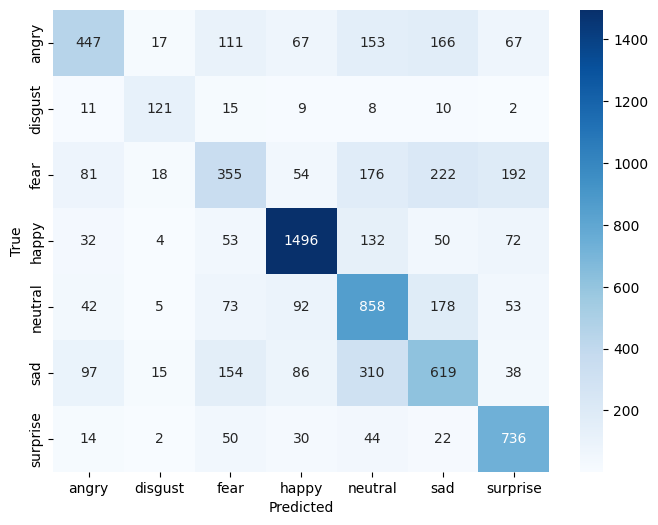

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(accum_model.predict(test_gen), axis=1)

print(classification_report(
    test_gen.classes,
    y_pred,
    target_names=test_gen.class_indices.keys()
))

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [17]:
import os, shutil

# aynı isimde bir şey varsa temizle
p = "final_emotion_model2.keras"
if os.path.exists(p):
    if os.path.isdir(p): shutil.rmtree(p)
    else: os.remove(p)

model.save(p)  # <-- accum_model değil, model!
print("✅ Kaydedildi:", p)


✅ Kaydedildi: final_emotion_model2.keras


120/120 [==============================] - 23s 193ms/step - loss: 1.2590 - accuracy: 0.6048
Test Loss: 1.2590
Test Accuracy: 0.6048
120/120 [==============================] - 35s 281ms/step

=== Classification Report ===
              precision    recall  f1-score   support

       angry     0.6174    0.4348    0.5103      1028
     disgust     0.6648    0.6875    0.6760       176
        fear     0.4377    0.3233    0.3719      1098
       happy     0.8157    0.8135    0.8146      1839
     neutral     0.5104    0.6595    0.5755      1301
         sad     0.4886    0.4693    0.4787      1319
    surprise     0.6345    0.8196    0.7153       898

    accuracy                         0.6048      7659
   macro avg     0.5956    0.6011    0.5917      7659
weighted avg     0.6020    0.6048    0.5970      7659



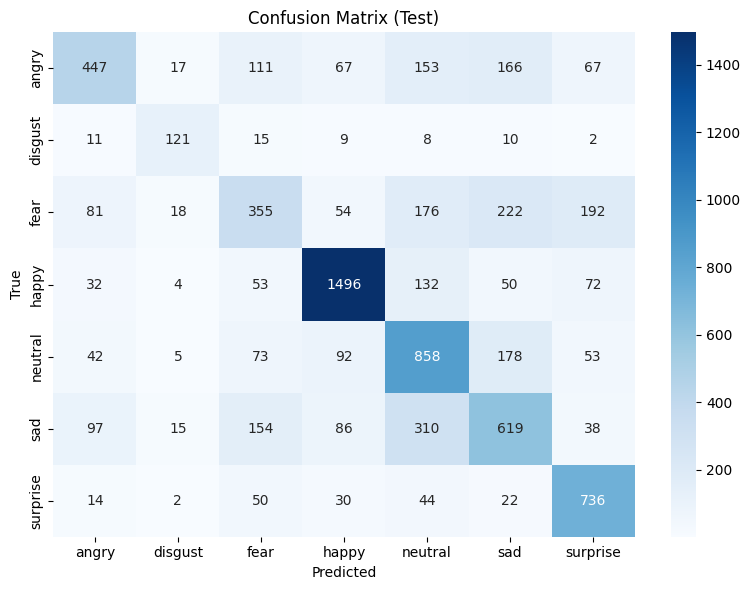

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# model: eğittiğin model (ör: stage2_model veya accum_model)
# test_gen: ImageDataGenerator ile oluşturduğun test generator

# 1) Test loss/accuracy
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# 2) Tahminler
probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(probs, axis=1)
y_true = test_gen.classes

# 3) Sınıf isimleri (index sırasına göre)
# class_indices: {'angry':0, 'disgust':1, ...}
idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]

# 4) Classification report (precision/recall/F1/support)
print("\n=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4
))

# 5) Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=target_names, yticklabels=target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.show()


In [19]:
from sklearn.metrics import f1_score, accuracy_score

print("Accuracy (sklearn):", accuracy_score(y_true, y_pred))
print("Macro-F1:", f1_score(y_true, y_pred, average="macro"))
print("Weighted-F1:", f1_score(y_true, y_pred, average="weighted"))


Accuracy (sklearn): 0.6047786917352135
Macro-F1: 0.5917441363210818
Weighted-F1: 0.5969909045321944


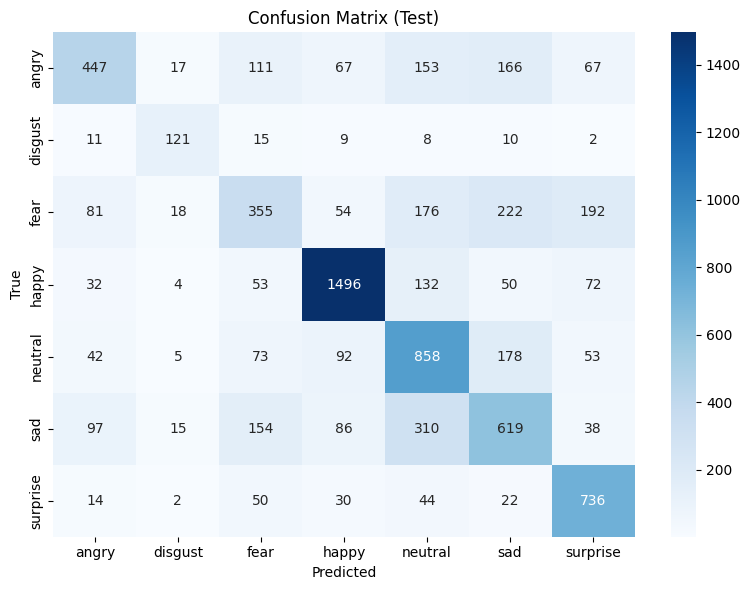

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig("confusion_matrix_test.png", dpi=200)
plt.show()


In [22]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                           